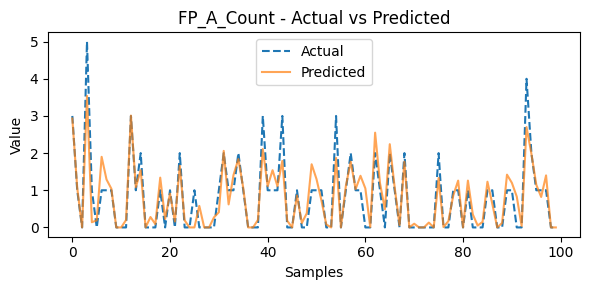

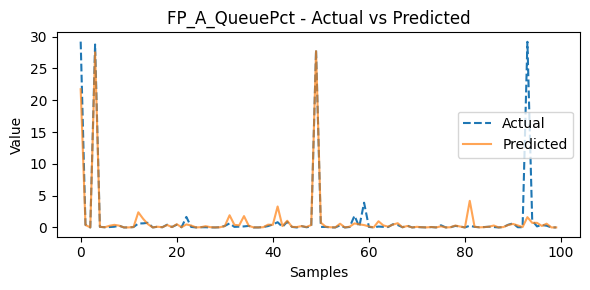

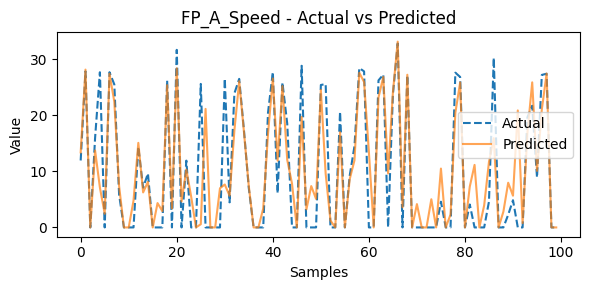

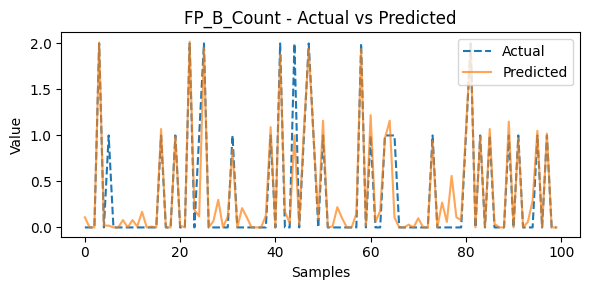

In [ ]:
# Multiple features




import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Load your CSV file
file_path = "junction_data_race_course (1).csv"  # Update path if needed
df = pd.read_csv("junction_data_race_course (1).csv")

# Function to create lag features
def create_lagged_features(data, lag=2):
    relevant_cols = [col for col in data.columns if any(k in col for k in ['Count', 'Speed', 'QueuePct'])]

    lagged = data[relevant_cols].copy()
    for l in range(1, lag + 1):
        for col in relevant_cols:
            lagged[f"{col}_lag{l}"] = data[col].shift(l)

    lagged = lagged.dropna().reset_index(drop=True)

    feature_cols = [col for col in lagged.columns if '_lag' in col]
    target_cols = [col for col in relevant_cols if col in lagged.columns]

    X = lagged[feature_cols]
    y = lagged[target_cols]
    return X, y, target_cols

# Main modeling function
def run_random_forest_prediction(df, lag=2):
    X, y, targets = create_lagged_features(df, lag=lag)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    models = {}
    predictions = {}
    metrics = {}

    for col in targets:
        model = RandomForestRegressor(n_estimators=100, random_state=42)
        model.fit(X_train, y_train[col])
        y_pred = model.predict(X_test)

        models[col] = model
        predictions[col] = y_pred
        mse = mean_squared_error(y_test[col], y_pred)
        r2 = r2_score(y_test[col], y_pred)
        metrics[col] = {'MSE': round(mse, 2), 'R2': round(r2, 2)}

        # Plot
        plt.figure(figsize=(6, 3))
        plt.plot(np.array(y_test[col].values[:100]), label="Actual", linestyle='--')
        plt.plot(y_pred[:100], label="Predicted", alpha=0.7)
        plt.title(f"{col} - Actual vs Predicted")
        plt.xlabel("Samples")
        plt.ylabel("Value")
        plt.legend()
        plt.tight_layout()
        plt.show()

    return metrics

# Set lag value here (change as needed)
lag_value = 2
results = run_random_forest_prediction(df, lag=lag_value)

# Print MSE and R² scores for all
print("Model Evaluation Metrics:\n")
for k, v in results.items():
    print(f"{k}: MSE={v['MSE']}, R²={v['R2']}")
